# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Heidi Williams

**Date:** 9/2/2026

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ML
#This line is used to connect the notebook to the correct folder and allow for it to be uploaded to the drive as I make changes

Mounted at /content/drive
/content/drive/MyDrive/ML


In [2]:
!git clone https://github.com/heidiwms/A01-data-wrangling
#this cell clones the repo to begin work

Cloning into 'A01-data-wrangling'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 16 (delta 2), reused 1 (delta 1), pack-reused 10 (from 1)
Receiving objects: 100% (16/16), 4.94 MiB | 9.17 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [10]:
#Question 1
%cd /A01-data-wrangling/data
!ls
#this cell is used to get to the correct directory and list the contents to make sure the desired csv file is there and it is

[Errno 2] No such file or directory: '/A01-data-wrangling/data'
/content/drive/MyDrive/ML/A01-data-wrangling/data
airbnb_hw.csv		      GSAF5.xls
airbnb_hw_solution_copy.xlsx  mn_police_use_of_force.csv


In [11]:
import pandas as pd
airbnb = pd.read_csv("./airbnb_hw.csv")
print(airbnb["Price"].head(20))
#This step reads the csv using pandas and then examines the first 20 rows of price to look at the values it gives and confims they are object variables

0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
Name: Price, dtype: object


In [12]:
airbnb["Price"]=airbnb["Price"].str.replace(",","",regex=False)
#remove the commas so the objects contain only numbers

In [13]:
airbnb["Price"]=pd.to_numeric(
    airbnb["Price"],
    errors="coerce"
)
#convert the object variables to numbers
print(airbnb["Price"].head(20))
print(airbnb["Price"].isna().sum())
print(airbnb["Price"].dtype)
#This confirms the conversion to numeric variables was sucessful and shows that there are no missing values

0     145
1      37
2      28
3     199
4     549
5     149
6     250
7      90
8     270
9     290
10    170
11     59
12     49
13     68
14    285
15     75
16    145
17    100
18    150
19    700
Name: Price, dtype: int64
0
int64


When I began coding this assignment, I first tried to convert the numbers to numeric before getting rid of the commas which resulted in 181 missing values. I realized my mistake, reloaded the data, and removed the commas before creating numeric data, so now there are 0 missing values.

In [14]:
#I decided to end by sorting the variable from lowest to highest price so that if the data needed to be analyzed it was in a convenient order
airbnb=airbnb.sort_values(by="Price")
print(airbnb["Price"].head(20))
airbnb.to_csv('clean_airbnb', index=False)

30087    10
3120     10
19275    10
9793     20
25139    20
18209    20
25916    21
19273    22
15228    24
15229    24
15230    24
5108     25
11255    25
21633    25
24570    25
23052    25
27127    25
24050    25
29089    25
15621    26
Name: Price, dtype: int64


In [15]:
#Question 1 part 2
policedf = pd.read_csv("./mn_police_use_of_force.csv")
print(policedf["subject_injury"].head(20))
print(len(policedf))
print(policedf["subject_injury"].isna().sum())
#This step reads the csv using pandas and then examines the first 20 rows of price to look at the values it gives and confims they are object variables

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
5     NaN
6     NaN
7     NaN
8     NaN
9      No
10     No
11    Yes
12    Yes
13    Yes
14     No
15     No
16    NaN
17    NaN
18    NaN
19     No
Name: subject_injury, dtype: object
12925
9848


9848 out of the 12925 rows have missing values. This means the proportion of missig values is 9848/12925 or about 76% of the values. This is a big concern, as over 3/4ths of the data set is missing these values, so cleaning is very important to create a useable dataset.

In [16]:
pd.crosstab(policedf["subject_injury"].fillna("Missing"), policedf["force_type"])

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
Missing,2,7051,1421,0,27,74,87,0,170,31,985
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172


A very large number (7051/9848) of the missing values in the subject injury category are from cases that listed the force type as bodily injury.

In [17]:
#cleaning the variable
policedf["subject_injury"] = (policedf["subject_injury"].str.strip().str.title())
policedf["subject_injury"].value_counts(dropna=False)
#I did this to make sure each Yes and No was identical (i.e. no leading or trailing spaces, all capitalized on the first letter only)

,count
subject_injury,
NaN,9848
Yes,1631
No,1446


In [18]:
#creating the subject_injury_cleaned column
policedf["subject_injury_cleaned"] = policedf["subject_injury"].copy()
policedf.loc[policedf["subject_injury"].isna() & (policedf["force_type"] == "Bodily Force"), "subject_injury_cleaned"] = "missing_bodily_force_case"
policedf.loc[policedf["subject_injury"].isna() & (policedf["force_type"] != "Bodily Force"), "subject_injury_cleaned"] = "missing_non_bodily_force_case"
policedf["subject_injury_cleaned"].value_counts(dropna=False)
policedf.to_csv('clean_police_csv', index=False)

I decided to create a new column called subject_injury_cleaned that had the cases listed as yes, no, missing_bodily_force_case, and missing_non_bodily_force_case. I decided against changing the missing data to something like "no" as no means no force in this set, not no data. The new subject_injury_cleaned column could now be used in analysis to understand not just which values are missing, but if that relation has to do with the force type being bodily injury or not just by reading the column.

In [19]:
#Question 2
!ls
sharkdf=pd.read_excel("GSAF5.xls")
print(sharkdf)
sharkdf=sharkdf.dropna(axis=1, how='all')
#this gets rid of columns that contain all null values
sharkdf = sharkdf.loc[:, ~sharkdf.columns.str.contains('^Unnamed')]
#this gets rid of unamed columns
print(sharkdf)

airbnb_hw.csv		      clean_airbnb	GSAF5.xls
airbnb_hw_solution_copy.xlsx  clean_police_csv	mn_police_use_of_force.csv
              Date    Year        Type             Country  \
0      26th August  2026.0  Unprovoked                 USA   
1     23rd August   2026.0  Unprovoked                 USA   
2      19th August  2026.0    Provoked      Reunion Island   
3      11th August  2026.0    Provoked             Ireland   
4       8th August  2026.0  Unprovoked                 USA   
...            ...     ...         ...                 ...   
7112   Before 1903     0.0  Unprovoked           AUSTRALIA   
7113   Before 1903     0.0  Unprovoked           AUSTRALIA   
7114     1900-1905     0.0  Unprovoked                 USA   
7115     1883-1889     0.0  Unprovoked              PANAMA   
7116     1845-1853     0.0  Unprovoked  CEYLON (SRI LANKA)   

                        State                             Location  \
0                      Hawaii          Ala Moana Beach Park, Oah'u 

In [20]:
#cleaning the year variable
sharkdf["Year"] = pd.to_numeric(sharkdf["Year"], errors="coerce")
sharkdf["Year"] = sharkdf["Year"].replace(0, pd.NA)
#this changes the value of 0 to missing, as the year is not available for this data, the year is not 'year 0'
print(sharkdf["Year"].value_counts().sort_index())
#By looking at the number of each value, I see that year 5 is the earliest year available, and year 2026 is the most recent
#range: 2021 years

Year
5.0         1
77.0        1
1000.0      1
1500.0      1
1518.0      1
         ... 
2022.0     98
2023.0    109
2024.0     52
2025.0     69
2026.0     53
Name: count, Length: 260, dtype: int64


I first tried to find the min and max of the "year" column to manually calculate the range, but this produced an incorrect range of 2026, as attacks without a year listed or those that are in the years B.C are listed as "0".

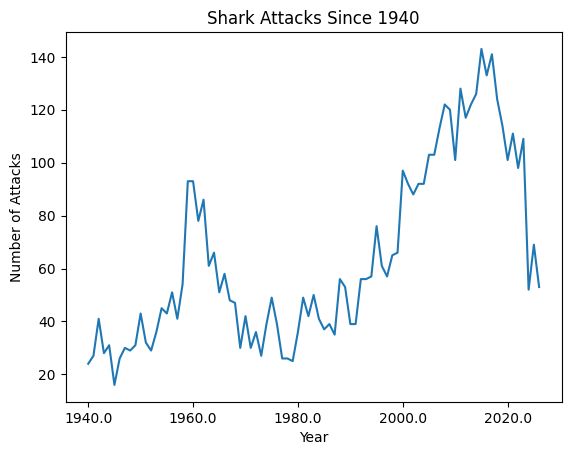

In [23]:
#sorting attacks since 1940
import matplotlib.pyplot as plt
sharkdf_1940 = sharkdf[sharkdf["Year"] >= 1940]
attacks_per_year = sharkdf_1940["Year"].value_counts().sort_index()
attacks_per_year.plot()
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.title("Shark Attacks Since 1940")
plt.show()
#The graph shows a notable increase in attacks since 1940 with two spikes, one around 1960 and one around 2015

In [46]:
#Cleaning age variable
sharkdf["Age"].value_counts(dropna=False)
#looking at the data, it makes sense to drop any ranges or data entered as a form that is not just a single number
#quickly strip leading or trailing spaces
sharkdf["Age_clean"] = sharkdf["Age"].astype("string").str.strip()
#coerce is important in the next line as it will force any non-numeric values to Nan
sharkdf["Age_clean"] = pd.to_numeric(sharkdf["Age"], errors="coerce")
sharkdf["Age_clean"].describe()

,Age_clean
count,3948.0
mean,28.197315
std,14.697518
min,1.0
25%,17.0
50%,24.0
75%,37.0
max,87.0


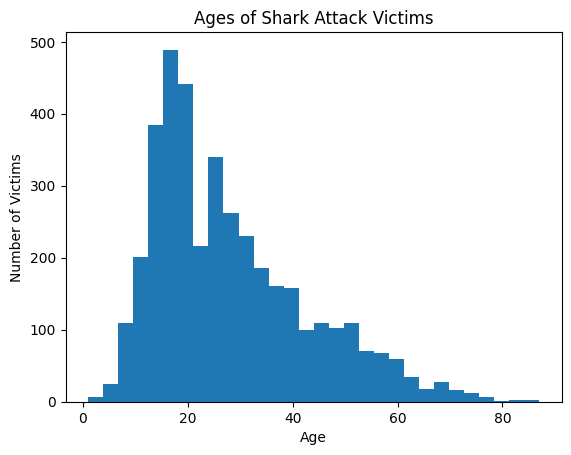

In [28]:
#this code creates the histogram
plt.hist(sharkdf["Age_clean"].dropna(), bins=30)
plt.xlabel("Age")
plt.ylabel("Number of Victims")
plt.title("Ages of Shark Attack Victims")
plt.show()

In [31]:
#what proportion are male
#quick clean of sex column
sharkdf["Sex_clean"] = sharkdf["Sex"].astype("string").str.strip().str.upper()
sharkdf["Sex_clean"].value_counts(dropna=False)

,count
Sex_clean,
M,5713
F,818
<NA>,578
?,2
N,2
M F,1
LLI,1
M X 2,1
.,1


In [39]:
#looking just at the rows with a listed sex
known_sex = sharkdf[sharkdf["Sex_clean"].isin(["M", "F"])]
#find the num of males listed and the sum of all females and males listed
num_males = (sharkdf["Sex_clean"] == "M").sum()
num_male_female = sharkdf["Sex_clean"].isin(["M", "F"]).sum()
#use simple division to find the proportion of males and convert to a percentage by multiplying by 100
print("proportion of males=", num_males/num_male_female*100, "%")

proportion of males= 87.47511866482928 %


In [40]:
#
sharkdf["Type_clean"] = sharkdf["Type"].astype("string").str.strip()
sharkdf["Type_clean"] = sharkdf["Type_clean"].where(sharkdf["Type_clean"].isin(["Provoked", "Unprovoked"]),"Unknown")
sharkdf["Type_clean"].value_counts()
#by reading the counts we see the proportion of unprovoked is 5261/7117
#this comes out to 73.9% unprovoked attacks out of the total

,count
Type_clean,
Unprovoked,5261
Unknown,1207
Provoked,649


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

**Phase 1 commit SHA ID:** [736b7dd4b7b638a0fec13410e9eb26f5c43d5563]
- **AI tool and model used:** [ChatGbt; model GPT-5.6 Sol ]

### *Prompts used

1. [Go through this notebook and give me a numbered list of the errors you see]

### *AI-proposed changes


1. The directory path in the Question 1 setup is incorrect.
%cd /A01-data-wrangling/data looks for the folder at the root of the Colab filesystem and produces [Errno 2] No such file or directory. It should point to the actual cloned repository, such as /content/drive/MyDrive/ML/A01-data-wrangling/data. On a fresh runtime, the incorrect path could cause the following read_csv() commands to fail.
2. The cleaned subject_injury variable should not contain information from force_type.
The values "missing_bodily_force_case" and "missing_non_bodily_force_case" mix two separate variables together. subject_injury_cleaned should represent injury status only, such as Yes, No, and a missing value. If the relationship between missing injury values and force type needs to be studied, that should be done with the cross-tabulation.
3. The explanation of No in subject_injury is incorrect.
The notebook says "no means no force in this set". A value of No means that the subject was recorded as not injured, not that no police force was used. force_type already records the type of force used.
4. The interpretation of the missing subject_injury values uses the wrong category name and does not fully describe the pattern.
The notebook refers to "bodily injury", but the actual force_type category is "Bodily Force". Also, simply noting that 7,051 of the missing observations involve bodily force does not fully answer whether missingness depends on force type. The proportions missing within each force type would give a clearer comparison.
5. The subject_injury_cleaned.value_counts() output is never displayed.
In the cell creating subject_injury_cleaned, value_counts(dropna=False) is followed by to_csv(), so its result is not displayed. It should be wrapped in print() or display() if it is being used to verify the cleaning.
6. The Age cleaning code strips spaces but then ignores the stripped variable.
The code correctly creates:
sharkdf["Age_clean"] = sharkdf["Age"].astype("string").str.strip()
but the next line converts the original sharkdf["Age"] instead of sharkdf["Age_clean"]. The numeric conversion should use the already stripped Age_clean column.
7. The Sex variable is not completely cleaned.
After stripping spaces and converting to uppercase, invalid values such as "?", "N", "M F", "LLI", "M X 2", and "." remain. These should normally be converted to missing/unknown so that the cleaned variable contains only valid categories such as M, F, and missing.
8. The denominator used for the proportion of male victims needs to be explicitly explained.
The current result of 87.48% is the proportion male among victims whose sex is recorded as either M or F, not the proportion among all 7,117 observations. The notebook should state this denominator so the answer is not interpreted as 87.48% of every victim in the dataset.
9. The Year discussion should distinguish the mathematical range from unusual historical values.
After converting 0 to missing, the notebook reports years as early as 5 and 77. These are extreme values that should at least be acknowledged rather than simply stating "range: 2021 years". It is clearer to say the non-missing numeric years span from 5 to 2026 and note that the earliest historical observations are unusual.
10. The cleaned CSV files are saved without .csv extensions.
to_csv('clean_airbnb', ...) and to_csv('clean_police_csv', ...) create CSV-formatted files, but the filenames do not end in .csv. Using clean_airbnb.csv and clean_police.csv would make the file type clear.

The most important fixes are #1, #2, #3, #6, and #7. The rest are mainly interpretation, verification, or reproducibility issues.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | reject | This is a reproducibility concern but does not describe something that I actually got wrong in the assignment. |
| 2 |  reject | I did this on purpose to visualize the data in a new column that highlighted the results of the cross tabulation.|
| 3 | Accept | This was a legit mistake on my part. I changed the comment to reflect this.|
| 4 | reject | I believe that my interpretation is also acceptable since this is a rather open-ended assignment.|
| 5 | reject | This line was run before I coded the rest of the block, so the output was displayed when needed for confirmation. |
| 6 | Accept  | Simple mistake on my end. I went back and edited this variable. The result did not change, most likely due to their being no leading or trailing spaces to remove in the first place, which is a lucky result. The way it is coded now is more acceptable and cleaner. |
| 7 | reject | This is functionally done in the next code block already. |
| 8 | Accept  | I added a line that clarifies this.|
| 9 | reject | This seems like a preference. I think what I did is acceptable too. |
| 10 | reject | Again, seems like this is a preference not a legitamate error. |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/ML
#This line is used to connect the notebook to the correct folder and allow for it to be uploaded to the drive as I make changes


In [ ]:
!git clone https://github.com/heidiwms/A01-data-wrangling
#this cell clones the repo to begin work

In [ ]:
#Question 1
%cd /A01-data-wrangling/data
!ls
#this cell is used to get to the correct directory and list the contents to make sure the desired csv file is there and it is

In [ ]:
import pandas as pd
airbnb = pd.read_csv("./airbnb_hw.csv")
print(airbnb["Price"].head(20))
#This step reads the csv using pandas and then examines the first 20 rows of price to look at the values it gives and confims they are object variables

In [ ]:
airbnb["Price"]=airbnb["Price"].str.replace(",","",regex=False)
#remove the commas so the objects contain only numbers
airbnb["Price"]=pd.to_numeric(
    airbnb["Price"],
    errors="coerce"
)
#convert the object variables to numbers
print(airbnb["Price"].head(20))
print(airbnb["Price"].isna().sum())
print(airbnb["Price"].dtype)
#This confirms the conversion to numeric variables was sucessful and shows that there are no missing values

When I began coding this assignment, I first tried to convert the numbers to numeric before getting rid of the commas which resulted in 181 missing values. I realized my mistake, reloaded the data, and removed the commas before creating numeric data, so now there are 0 missing values.

In [ ]:
#I decided to end by sorting the variable from lowest to highest price so that if the data needed to be analyzed it was in a convenient order
airbnb=airbnb.sort_values(by="Price")
print(airbnb["Price"].head(20))
airbnb.to_csv('clean_airbnb', index=False)

In [ ]:
#Question 1 part 2
policedf = pd.read_csv("./mn_police_use_of_force.csv")
print(policedf["subject_injury"].head(20))
print(len(policedf))
print(policedf["subject_injury"].isna().sum())
#This step reads the csv using pandas and then examines the first 20 rows of price to look at the values it gives and confims they are object variables

9848 out of the 12925 rows have missing values. This means the proportion of missig values is 9848/12925 or about 76% of the values. This is a big concern, as over 3/4ths of the data set is missing these values, so cleaning is very important to create a useable dataset.

In [ ]:
pd.crosstab(policedf["subject_injury"].fillna("Missing"), policedf["force_type"])

A very large number (7051/9848) of the missing values in the subject injury category are from cases that listed the force type as bodily injury.

In [ ]:
#cleaning the variable
policedf["subject_injury"] = (policedf["subject_injury"].str.strip().str.title())
policedf["subject_injury"].value_counts(dropna=False)
#I did this to make sure each Yes and No was identical (i.e. no leading or trailing spaces, all capitalized on the first letter only)

In [ ]:
#creating the subject_injury_cleaned column
policedf["subject_injury_cleaned"] = policedf["subject_injury"].copy()
policedf.loc[policedf["subject_injury"].isna() & (policedf["force_type"] == "Bodily Force"), "subject_injury_cleaned"] = "missing_bodily_force_case"
policedf.loc[policedf["subject_injury"].isna() & (policedf["force_type"] != "Bodily Force"), "subject_injury_cleaned"] = "missing_non_bodily_force_case"
policedf["subject_injury_cleaned"].value_counts(dropna=False)
policedf.to_csv('clean_police_csv', index=False)

I decided to create a new column called subject_injury_cleaned that had the cases listed as yes, no, missing_bodily_force_case, and missing_non_bodily_force_case. I decided against changing the missing data to something like "no" as no means no injury in this set, not no data. The new subject_injury_cleaned column could now be used in analysis to understand not just which values are missing, but if that relation has to do with the force type being bodily injury or not just by reading the column.

In [ ]:
#Question 2
!ls
sharkdf=pd.read_excel("GSAF5.xls")
print(sharkdf)
sharkdf=sharkdf.dropna(axis=1, how='all')
#this gets rid of columns that contain all null values
sharkdf = sharkdf.loc[:, ~sharkdf.columns.str.contains('^Unnamed')]
#this gets rid of unamed columns
print(sharkdf)

In [ ]:
#cleaning the year variable
sharkdf["Year"] = pd.to_numeric(sharkdf["Year"], errors="coerce")
sharkdf["Year"] = sharkdf["Year"].replace(0, pd.NA)
#this changes the value of 0 to missing, as the year is not available for this data, the year is not 'year 0'
print(sharkdf["Year"].value_counts().sort_index())
#By looking at the number of each value, I see that year 5 is the earliest year available, and year 2026 is the most recent
#range: 2021 years

I first tried to find the min and max of the "year" column to manually calculate the range, but this produced an incorrect range of 2026, as attacks without a year listed or those that are in the years B.C are listed as "0".

In [ ]:
#sorting attacks since 1940
import matplotlib.pyplot as plt
sharkdf_1940 = sharkdf[sharkdf["Year"] >= 1940]
attacks_per_year = sharkdf_1940["Year"].value_counts().sort_index()
attacks_per_year.plot()
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.title("Shark Attacks Since 1940")
plt.show()
#The graph shows a notable increase in attacks since 1940 with two spikes, one around 1960 and one around 2015

In [ ]:
#Cleaning age variable
sharkdf["Age"].value_counts(dropna=False)
#looking at the data, it makes sense to drop any ranges or data entered as a form that is not just a single number
#quickly strip leading or trailing spaces
sharkdf["Age_clean"] = sharkdf["Age"].astype("string").str.strip()
#coerce is important in the next line as it will force any non-numeric values to Nan
sharkdf["Age_clean"] = pd.to_numeric(sharkdf["Age_clean"], errors="coerce")
sharkdf["Age_clean"].describe()

In [ ]:
#this code creates the histogram
plt.hist(sharkdf["Age_clean"].dropna(), bins=30)
plt.xlabel("Age")
plt.ylabel("Number of Victims")
plt.title("Ages of Shark Attack Victims")
plt.show()

In [ ]:
#what proportion are male
#quick clean of sex column
sharkdf["Sex_clean"] = sharkdf["Sex"].astype("string").str.strip().str.upper()
sharkdf["Sex_clean"].value_counts(dropna=False)

In [ ]:
#looking just at the rows with a listed sex
known_sex = sharkdf[sharkdf["Sex_clean"].isin(["M", "F"])]
#find the num of males listed and the sum of all females and males listed
num_males = (sharkdf["Sex_clean"] == "M").sum()
num_male_female = sharkdf["Sex_clean"].isin(["M", "F"]).sum()
#use simple division to find the proportion of males and convert to a percentage by multiplying by 100
print("proportion of males=", num_males/num_male_female*100, "%")
#to clarify, the denominator is just those recored as male or female, not the total data

In [ ]:
#stripping trailing and leading white spaces
sharkdf["Type_clean"] = sharkdf["Type"].astype("string").str.strip()
sharkdf["Type_clean"] = sharkdf["Type_clean"].where(sharkdf["Type_clean"].isin(["Provoked", "Unprovoked"]),"Unknown")
sharkdf["Type_clean"].value_counts()
#by reading the counts we see the proportion of unprovoked is 5261/7117
#this comes out to 73.9% unprovoked attacks out of the total

### *Reflection on AI assistance
In your own words without generative AI.

AI caught a few things that I could explain better or label to make reproducibility easier. I think the biggest limitation is in understanding why I made certain choices. A human reviewing this assignment could read my comments and understand why I did what I did, but AI had trouble interpreting things like this. For example, AI told me I could cross-tabulate to understand the police data, but I did do that, I just created the new data column with the missing data labeled as whether or not it came from a bodily force line for better visualization. A human would most likely see my comments and understand this choice, but AI simply sees one block at a time in isolation. The final solution was simply verified by me; I decided what to keep based on my intuition for if the task was necessary or if it was a stylistic change that was not necessary for this assignment. There could be a better way for me to verify this.